In [66]:
from pathlib import Path
import json
import pandas as pd

DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd() / "week08" / "data"
OUTPUT = Path.cwd() / "output" if (Path.cwd() / "data").exists() else Path.cwd() / "week08" / "output"
OUTPUT.mkdir(exist_ok=True)


# TODO 5: Validate business rules ก่อนคำนวณยอดขาย
# TODO 6: Load dim_customer.csv, dim_product.csv และ fact_sales.csv
# TODO 7: สร้าง summary_by_province.csv และ summary_by_category.csv

print("เริ่มทำ Data Integration ได้เลย")
print(f"DATA path: {DATA}")
print(f"OUTPUT path: {OUTPUT}")

เริ่มทำ Data Integration ได้เลย
DATA path: /Users/gatunyu/Documents/J_Tea_Work/dw_lab/week08/data
OUTPUT path: /Users/gatunyu/Documents/J_Tea_Work/dw_lab/week08/output


In [67]:
# TODO 1: Extract ข้อมูลจาก CSV, Excel และ JSON
pd.set_option('display.max_columns', 50)
raw_customers = pd.read_csv(DATA / "customers_crm.csv")
raw_orders_01 = pd.read_csv(DATA / "orders_2026_01.csv")
raw_orders_02 = pd.read_csv(DATA / "orders_2026_02.csv")
raw_products  = pd.read_excel(DATA / "product_master.xlsx")
raw_payments  = pd.read_json(DATA / "payments.json")

df_customers = raw_customers.copy()
df_orders_01 = raw_orders_01.copy()
df_orders_02 = raw_orders_02.copy()
df_products  = raw_products.copy()
df_payments  = raw_payments.copy()

dataframes = [
    ("Customers CRM", df_customers),
    ("Orders 2026-01", df_orders_01),
    ("Orders 2026-02", df_orders_02),
    ("Product Master", df_products),
    ("Payments", df_payments)
]
for name, df in dataframes:
    print("=" * 50)
    print(f" {name} (Shape: {df.shape} ; Columns: { df.shape[1]} ; \n\nDtype: {df.dtypes}) \n\nMissing Values: {df.isnull().sum()} \n\nDuplicate: {df.astype(str).duplicated().sum()}")
    print("=" * 50)
    display(df.head())



 Customers CRM (Shape: (163, 5) ; Columns: 5 ; 

Dtype: customer_id    object
full_name      object
email          object
province       object
signup_date    object
dtype: object) 

Missing Values: customer_id    0
full_name      0
email          5
province       0
signup_date    0
dtype: int64 

Duplicate: 0


,customer_id,full_name,email,province,signup_date
0,C0001,ลูกค้า 001,customer001@example.com,ชลบุรี,2024-07-29
1,C0002,ลูกค้า 002,customer002@example.com,Chonburi,2025-01-04
2,C0003,ลูกค้า 003,customer003@example.com,ขอนแก่น,2025-10-10
3,C0004,ลูกค้า 004,customer004@example.com,กรุงเทพมหานคร,2024-07-11
4,C0005,ลูกค้า 005,customer005@example.com,ระยอง,2025-06-27


 Orders 2026-01 (Shape: (361, 8) ; Columns: 8 ; 

Dtype: order_id        object
order_date      object
customer_id     object
product_id      object
quantity         int64
unit_price     float64
discount       float64
channel         object
dtype: object) 

Missing Values: order_id       0
order_date     0
customer_id    0
product_id     0
quantity       0
unit_price     1
discount       0
channel        0
dtype: int64 

Duplicate: 1


,order_id,order_date,customer_id,product_id,quantity,unit_price,discount,channel
0,ORD000001,2026-01-08 17:11:00,C0158,P039,2,940.5,0.00,Marketplace
1,ORD000002,2026-01-12 20:13:00,C0123,P038,1,12900.0,0.10,Mobile App
2,ORD000003,2026-01-26 14:00:00,C0119,P031,3,1415.5,0.05,Web
3,ORD000004,2026-01-18 16:18:00,C0065,P003,2,25900.0,0.00,Mobile App
4,ORD000005,2026-01-08 17:43:00,C0129,P007,2,23310.0,0.05,Mobile App


 Orders 2026-02 (Shape: (391, 8) ; Columns: 8 ; 

Dtype: order_id         object
ordered_at       object
customer_id      object
product_id       object
qty               int64
unit_price      float64
discount_pct     object
channel          object
dtype: object) 

Missing Values: order_id        0
ordered_at      0
customer_id     0
product_id      0
qty             0
unit_price      1
discount_pct    0
channel         0
dtype: int64 

Duplicate: 1


,order_id,ordered_at,customer_id,product_id,qty,unit_price,discount_pct,channel
0,ORD000361,19/02/2026 02:59,C0124,P019,1,4189.5,5%,Web
1,ORD000362,20/02/2026 07:33,C0072,P039,2,940.5,5%,Web
2,ORD000363,08/02/2026 06:17,C0136,P014,2,940.5,5%,Mobile App
3,ORD000364,16/02/2026 06:58,C0077,P038,2,12900.0,0%,Web
4,ORD000365,23/02/2026 13:30,C0139,P004,2,1490.0,0%,Marketplace


 Product Master (Shape: (40, 5) ; Columns: 5 ; 

Dtype: product_id        object
product_name      object
category          object
standard_price     int64
active_flag       object
dtype: object) 

Missing Values: product_id        0
product_name      0
category          0
standard_price    0
active_flag       0
dtype: int64 

Duplicate: 0


,product_id,product_name,category,standard_price,active_flag
0,P001,Notebook Model 01,Notebook,299,Y
1,P002,Smartphone Model 02,Smartphone,1490,Y
2,P003,Smartphone Model 03,Smartphone,25900,Y
3,P004,Smart Home Model 04,Smart Home,1490,Y
4,P005,Smartphone Model 05,Smartphone,299,Y


 Payments (Shape: (752, 4) ; Columns: 4 ; 

Dtype: payment_id            object
order_id              object
payment               object
paid_at       datetime64[ns]
dtype: object) 

Missing Values: payment_id    0
order_id      0
payment       0
paid_at       0
dtype: int64 

Duplicate: 1


,payment_id,order_id,payment,paid_at
0,PAY000001,ORD000001,"{'method': 'Bank Transfer', 'status': 'PAID'}",2026-01-08 17:30:00
1,PAY000002,ORD000002,"{'method': 'Bank Transfer', 'status': 'PAID'}",2026-01-12 22:58:00
2,PAY000003,ORD000003,"{'method': 'PromptPay', 'status': 'PAID'}",2026-01-26 14:03:00
3,PAY000004,ORD000004,"{'method': 'Bank Transfer', 'status': 'PAID'}",2026-01-18 18:24:00
4,PAY000005,ORD000005,"{'method': 'Credit Card', 'status': 'PAID'}",2026-01-08 20:03:00


In [68]:
# TODO 2: ทำ schema alignment ของไฟล์ orders สองเดือน แล้ว concat
df_orders_02 = df_orders_02.rename(columns={
    "ordered_at": "order_date",
    "qty": "quantity",
    "discount_pct": "discount"
})

#change % to float
df_orders_02["discount"] = (
    df_orders_02["discount"]
    .astype(str)
    .str.rstrip("%")
    .astype(float) / 100.0
)

#concat order01 and order02
df_orders = pd.concat([df_orders_01, df_orders_02], ignore_index=True)

# แสดงผลการตรวจสอบ
print(f"จำนวนแถว Orders ม.ค. (01): {len(df_orders_01)}")
print(f"จำนวนแถว Orders ก.พ. (02): {len(df_orders_02)}")
print(f"จำนวนแถวหลัง Concat (รวม): {len(df_orders)}")
display(df_orders.head(10))

จำนวนแถว Orders ม.ค. (01): 361
จำนวนแถว Orders ก.พ. (02): 391
จำนวนแถวหลัง Concat (รวม): 752


,order_id,order_date,customer_id,product_id,quantity,unit_price,discount,channel
0,ORD000001,2026-01-08 17:11:00,C0158,P039,2,940.50,0.00,Marketplace
1,ORD000002,2026-01-12 20:13:00,C0123,P038,1,12900.00,0.10,Mobile App
2,ORD000003,2026-01-26 14:00:00,C0119,P031,3,1415.50,0.05,Web
3,ORD000004,2026-01-18 16:18:00,C0065,P003,2,25900.00,0.00,Mobile App
4,ORD000005,2026-01-08 17:43:00,C0129,P007,2,23310.00,0.05,Mobile App
5,ORD000006,2026-01-23 11:50:00,C0097,P037,2,27195.00,0.00,Mobile App
6,ORD000007,2026-01-24 07:03:00,C0139,P001,1,284.05,0.00,Web
7,ORD000008,2026-01-12 16:02:00,C0060,P013,-1,523.95,0.05,Mobile App
8,ORD000009,2026-01-16 04:12:00,C0162,P017,1,990.00,0.05,Web
9,ORD000010,2026-01-07 03:12:00,C0100,P017,2,990.00,0.10,Mobile App


In [69]:
# TODO 3: Clean/standardize/deduplicate และสร้าง data quality report

dq_logs = []
# 1. Standardize
# 1.1 Trim & Lowercase Email
df_customers["email"] = df_customers["email"].astype(str).str.strip().str.lower()
df_customers["full_name"] = df_customers["full_name"].astype(str).str.strip()

# 1.2 Standardize ชื่อจังหวัด (Province Mapping)
province_mapping = {
    # กรุงเทพมหานคร
    "bangkok": "กรุงเทพมหานคร",
    "กทม.": "กรุงเทพมหานคร",
    "กรุงเทพมหานคร": "กรุงเทพมหานคร",
    # ชลบุรี
    "chonburi": "ชลบุรี",
    "ชลบุรี": "ชลบุรี",
    # เชียงใหม่
    "chiang mai": "เชียงใหม่",
    "เชียงใหม่": "เชียงใหม่",
    # ขอนแก่น 
    "khon kaen": "ขอนแก่น",
    "ขอนเเก่น": "ขอนแก่น",
    "ขอนแก่น": "ขอนแก่น",
    # ภูเก็ต
    "phuket": "ภูเก็ต",
    "ภูเก็ต": "ภูเก็ต",
    # ระยอง
    "rayong": "ระยอง",
    "ระยอง": "ระยอง"
}

df_customers["province"] = (
    df_customers["province"]
    .astype(str)
    .str.strip()
    .apply(lambda p: province_mapping.get(p.lower(), province_mapping.get(p, p)))
)

# 1.3 แปลงชนิดข้อมูล วันที่สมัคร
df_customers["signup_date"] = pd.to_datetime(df_customers["signup_date"])

# 1.4 ตรวจสอบและ Deduplicate ลูกค้า 
dup_cust_count = df_customers["customer_id"].duplicated(keep="last").sum()
if dup_cust_count > 0:
    dq_logs.append({
        "table": "customers_crm",
        "issue": "Duplicate customer_id",
        "count": int(dup_cust_count),
        "action": "Removed duplicates keeping the last occurrence"
    })
    df_customers = df_customers.drop_duplicates(subset=["customer_id"], keep="last").reset_index(drop=True)


# 2. Clean & Deduplicate: df_orders
# 2.1 แปลงชนิดข้อมูล
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"], format="mixed")
df_orders["quantity"] = pd.to_numeric(df_orders["quantity"])
df_orders["unit_price"] = pd.to_numeric(df_orders["unit_price"])
df_orders["discount"] = pd.to_numeric(df_orders["discount"])

# 2.2 ตรวจสอบ Duplicate order_id
dup_orders_count = df_orders["order_id"].duplicated(keep="last").sum()
if dup_orders_count > 0:
    dq_logs.append({
        "table": "orders",
        "issue": "Duplicate order_id",
        "count": int(dup_orders_count),
        "action": "Removed duplicate order_id keeping the last occurrences"
    })
    df_orders = df_orders.drop_duplicates(subset=["order_id"], keep="last").reset_index(drop=True)


# 3. สรุปผล
df_dq_report = pd.DataFrame(dq_logs)
df_dq_report.to_csv(OUTPUT / "data_quality_report.csv", index=False, encoding="utf-8-sig")

print("สรุปผล Data Cleaning & Deduplication")
print(f"Customers shape : ก่อนคลีน {raw_customers.shape} -> หลังคลีน {df_customers.shape} (ลดลง {len(raw_customers) - len(df_customers)} แถว)")
# เปรียบเทียบ Orders (รวม 2 เดือน)
raw_orders_total_len = len(raw_orders_01) + len(raw_orders_02)
print(f"Orders shape    : ก่อนคลีน ({raw_orders_total_len}, {df_orders.shape[1]}) -> หลังคลีน {df_orders.shape} (ลดลง {raw_orders_total_len - len(df_orders)} แถว)")
print("\n📊 Data Quality Report:")

display(df_dq_report)


สรุปผล Data Cleaning & Deduplication
Customers shape : ก่อนคลีน (163, 5) -> หลังคลีน (160, 5) (ลดลง 3 แถว)
Orders shape    : ก่อนคลีน (752, 8) -> หลังคลีน (750, 8) (ลดลง 2 แถว)

📊 Data Quality Report:


,table,issue,count,action
0,customers_crm,Duplicate customer_id,3,Removed duplicates keeping the last occurrence
1,orders,Duplicate order_id,2,Removed duplicate order_id keeping the last oc...


In [70]:
# TODO 4: Enrich ด้วย customer, product และ payment master

# 1. เตรียม df_payments ให้พร้อม merge
with open(DATA / "payments.json", "r", encoding="utf-8") as f:
    raw_p = json.load(f)

df_payments_flat = pd.json_normalize(raw_p).rename(columns={
    "payment.method": "payment_method",
    "payment.status": "payment_status"
})
df_payments_flat = df_payments_flat.drop_duplicates(subset=["order_id"], keep="last").reset_index(drop=True)

# 2. ทำการ Merge และตรวจสอบความถูกต้องทีละ Maste
# 2.1 Merge กับ Customer Master (Orders: many, Customers: one)
merged_cust = df_orders.merge(
    df_customers,
    on="customer_id",
    how="left",
    validate="many_to_one",
    indicator="_cust_match"
)

# 2.2 Merge กับ Product Master (Orders: many, Products: one)
merged_prod = merged_cust.merge(
    df_products,
    on="product_id",
    how="left",
    validate="many_to_one",
    indicator="_prod_match"
)

# 2.3 Merge กับ Payment Master (Orders: one, Payments: one)
df_enriched = merged_prod.merge(
    df_payments_flat,
    on="order_id",
    how="left",
    validate="one_to_one",
    indicator="_pay_match"
)

# 3. สรุปผล Matched / Unmatche
merge_summary = pd.DataFrame([
    {
        "Master Data": "Customers CRM",
        "Matched (both)": (df_enriched["_cust_match"] == "both").sum(),
        "Unmatched (left_only)": (df_enriched["_cust_match"] == "left_only").sum(),
        "Match Rate (%)": f"{(df_enriched['_cust_match'] == 'both').mean() * 100:.2f}%"
    },
    {
        "Master Data": "Product Master",
        "Matched (both)": (df_enriched["_prod_match"] == "both").sum(),
        "Unmatched (left_only)": (df_enriched["_prod_match"] == "left_only").sum(),
        "Match Rate (%)": f"{(df_enriched['_prod_match'] == 'both').mean() * 100:.2f}%"
    },
    {
        "Master Data": "Payments",
        "Matched (both)": (df_enriched["_pay_match"] == "both").sum(),
        "Unmatched (left_only)": (df_enriched["_pay_match"] == "left_only").sum(),
        "Match Rate (%)": f"{(df_enriched['_pay_match'] == 'both').mean() * 100:.2f}%"
    }
])

print("สรุปผลการ Merge Master Data (Matched vs Unmatched):")
display(merge_summary)

print(f"\nEnriched DataFrame Shape: {df_enriched.shape}")
display(df_enriched.head())


สรุปผลการ Merge Master Data (Matched vs Unmatched):


,Master Data,Matched (both),Unmatched (left_only),Match Rate (%)
0,Customers CRM,728,22,97.07%
1,Product Master,748,2,99.73%
2,Payments,750,0,100.00%



Enriched DataFrame Shape: (750, 23)


,order_id,order_date,customer_id,product_id,quantity,unit_price,discount,channel,full_name,email,province,signup_date,_cust_match,product_name,category,standard_price,active_flag,_prod_match,payment_id,paid_at,payment_method,payment_status,_pay_match
0,ORD000001,2026-01-08 17:11:00,C0158,P039,2,940.5,0.00,Marketplace,ลูกค้า 158,customer158@example.com,เชียงใหม่,2024-02-23,both,Notebook Model 39,Notebook,990.0,N,both,PAY000001,2026-01-08T17:30:00,Bank Transfer,PAID,both
1,ORD000002,2026-01-12 20:13:00,C0123,P038,1,12900.0,0.10,Mobile App,ลูกค้า 123,customer123@example.com,ระยอง,2025-02-26,both,Smartphone Model 38,Smartphone,12900.0,N,both,PAY000002,2026-01-12T22:58:00,Bank Transfer,PAID,both
2,ORD000003,2026-01-26 14:00:00,C0119,P031,3,1415.5,0.05,Web,ลูกค้า 119,customer119@example.com,ขอนแก่น,2024-12-12,both,Smart Home Model 31,Smart Home,1490.0,Y,both,PAY000003,2026-01-26T14:03:00,PromptPay,PAID,both
3,ORD000004,2026-01-18 16:18:00,C0065,P003,2,25900.0,0.00,Mobile App,ลูกค้า 065,customer065@example.com,ขอนแก่น,2024-06-15,both,Smartphone Model 03,Smartphone,25900.0,Y,both,PAY000004,2026-01-18T18:24:00,Bank Transfer,PAID,both
4,ORD000005,2026-01-08 17:43:00,C0129,P007,2,23310.0,0.05,Mobile App,ลูกค้า 129,customer129@example.com,กรุงเทพมหานคร,2025-06-03,both,Notebook Model 07,Notebook,25900.0,Y,both,PAY000005,2026-01-08T20:03:00,Credit Card,PAID,both


In [71]:
# merge ได้ไม่ 100% เพราะมีข้อมูลไม่ตรงกันต้องจัดการ
# บันทึกความผิดปกติลง Data Quality Report ก่อนคัดออก
unmatched_cust_count = (df_enriched["_cust_match"] == "left_only").sum()
if unmatched_cust_count > 0:
    dq_logs.append({
        "table": "orders",
        "issue": "Customer ID not found in Master Data",
        "count": int(unmatched_cust_count),
        "action": "Filtered out unmapped customers (Rule 3)"
    })

unmatched_prod_count = (df_enriched["_prod_match"] == "left_only").sum()
if unmatched_prod_count > 0:
    dq_logs.append({
        "table": "orders",
        "issue": "Product ID not found in Master Data",
        "count": int(unmatched_prod_count),
        "action": "Filtered out unmapped products (Rule 3)"
    })

# กรองเฉพาะแถวที่ Match ครบทั้ง Customer และ Product 
df_valid_orders = df_enriched[
    (df_enriched["_cust_match"] == "both") & 
    (df_enriched["_prod_match"] == "both")
].copy()

print(f"ข้อมูล Orders ที่ Match พบใน Master ครบ 100% มีจำนวน: {len(df_valid_orders)} แถว")
# สรุปผล Matched / Unmatched จาก df_valid_orders ที่กรองแล้ว
valid_merge_summary = pd.DataFrame([
    {
        "Master Data": "Customers CRM",
        "Matched (both)": (df_valid_orders["_cust_match"] == "both").sum(),
        "Unmatched (left_only)": (df_valid_orders["_cust_match"] == "left_only").sum(),
        "Match Rate (%)": f"{(df_valid_orders['_cust_match'] == 'both').mean() * 100:.2f}%"
    },
    {
        "Master Data": "Product Master",
        "Matched (both)": (df_valid_orders["_prod_match"] == "both").sum(),
        "Unmatched (left_only)": (df_valid_orders["_prod_match"] == "left_only").sum(),
        "Match Rate (%)": f"{(df_valid_orders['_prod_match'] == 'both').mean() * 100:.2f}%"
    },
    {
        "Master Data": "Payments",
        "Matched (both)": (df_valid_orders["_pay_match"] == "both").sum(),
        "Unmatched (left_only)": (df_valid_orders["_pay_match"] == "left_only").sum(),
        "Match Rate (%)": f"{(df_valid_orders['_pay_match'] == 'both').mean() * 100:.2f}%"
    }
])

print("สรุปผลหลังกรอง Unmatched Master Data (Match Rate 100%):")
display(valid_merge_summary)

# แสดง Data Quality Report ที่อัปเดตล่าสุด
df_dq_report = pd.DataFrame(dq_logs)
print("\nData Quality Report ปัจจุบัน:")
display(df_dq_report)

# บันทึก Data Quality Report ลงไฟล์ CSV ในโฟลเดอร์ output
df_dq_report = pd.DataFrame(dq_logs)
df_dq_report.to_csv(OUTPUT / "data_quality_report.csv", index=False, encoding="utf-8-sig")





ข้อมูล Orders ที่ Match พบใน Master ครบ 100% มีจำนวน: 726 แถว
สรุปผลหลังกรอง Unmatched Master Data (Match Rate 100%):


,Master Data,Matched (both),Unmatched (left_only),Match Rate (%)
0,Customers CRM,726,0,100.00%
1,Product Master,726,0,100.00%
2,Payments,726,0,100.00%



Data Quality Report ปัจจุบัน:


,table,issue,count,action
0,customers_crm,Duplicate customer_id,3,Removed duplicates keeping the last occurrence
1,orders,Duplicate order_id,2,Removed duplicate order_id keeping the last oc...
2,orders,Customer ID not found in Master Data,22,Filtered out unmapped customers (Rule 3)
3,orders,Product ID not found in Master Data,2,Filtered out unmapped products (Rule 3)


In [72]:
# TODO 5: Validate business rules ก่อนคำนวณยอดขาย

# 1. ตรวจสอบ Rule 2: quantity > 0, unit_price > 0, discount อยู่ในช่วง [0, 1]
invalid_qty_mask = df_valid_orders["quantity"] <= 0
invalid_qty_count = invalid_qty_mask.sum()
if invalid_qty_count > 0:
    dq_logs.append({
        "table": "orders",
        "issue": "Invalid quantity (<= 0)",
        "count": int(invalid_qty_count),
        "action": "Filtered out rows with non-positive quantity (Rule 2)"
    })

invalid_price_mask = df_valid_orders["unit_price"] <= 0
invalid_price_count = invalid_price_mask.sum()
if invalid_price_count > 0:
    dq_logs.append({
        "table": "orders",
        "issue": "Invalid unit_price (<= 0)",
        "count": int(invalid_price_count),
        "action": "Filtered out rows with non-positive unit price (Rule 2)"
    })

invalid_discount_mask = (df_valid_orders["discount"] < 0) | (df_valid_orders["discount"] > 1)
invalid_discount_count = invalid_discount_mask.sum()
if invalid_discount_count > 0:
    dq_logs.append({
        "table": "orders",
        "issue": "Invalid discount (out of range [0, 1])",
        "count": int(invalid_discount_count),
        "action": "Filtered out rows with invalid discount range (Rule 2)"
    })


# 2. ตรวจสอบ Rule 4: นับเป็นยอดขายเมื่อ payment.status เท่ากับ PAID เท่านั้น
unpaid_mask = df_valid_orders["payment_status"] != "PAID"
unpaid_count = unpaid_mask.sum()
if unpaid_count > 0:
    dq_logs.append({
        "table": "payments",
        "issue": "Non-PAID payment status (FAILED/REFUNDED)",
        "count": int(unpaid_count),
        "action": "Excluded unpaid orders from sales calculation (Rule 4)"
    })


# 3. กรองเฉพาะรายการที่ Valid ทั้งหมดสำหรับคิดยอดขาย
valid_mask = (
    (~invalid_qty_mask) & 
    (~invalid_price_mask) & 
    (~invalid_discount_mask) & 
    (df_valid_orders["payment_status"] == "PAID")
)

df_sales_validated = df_valid_orders[valid_mask].copy()


# 4. คำนวณยอดขาย Rule 5: net_sales = quantity × unit_price × (1 - discount)
df_sales_validated["net_sales"] = (
    df_sales_validated["quantity"] * 
    df_sales_validated["unit_price"] * 
    (1.0 - df_sales_validated["discount"])
).round(2)


# 5. บันทึกและแสดง Data Quality Report ล่าสุด
df_dq_report = pd.DataFrame(dq_logs)
df_dq_report.to_csv(OUTPUT / "data_quality_report.csv", index=False, encoding="utf-8-sig")

print("Validation เสร็จสมบูรณ์")
print(f"จำนวนรายการขายที่ผ่านเกณฑ์ (PAID & Valid): {len(df_sales_validated)} แถว")
print(f"ยอดขายสุทธิรวม (Total Net Sales): {df_sales_validated['net_sales'].sum():,.2f} บาท")

print("\nสรุป Data Quality Report ทั้งหมด:")
display(df_dq_report)


Validation เสร็จสมบูรณ์
จำนวนรายการขายที่ผ่านเกณฑ์ (PAID & Valid): 662 แถว
ยอดขายสุทธิรวม (Total Net Sales): 10,224,044.09 บาท

สรุป Data Quality Report ทั้งหมด:


,table,issue,count,action
0,customers_crm,Duplicate customer_id,3,Removed duplicates keeping the last occurrence
1,orders,Duplicate order_id,2,Removed duplicate order_id keeping the last oc...
2,orders,Customer ID not found in Master Data,22,Filtered out unmapped customers (Rule 3)
3,orders,Product ID not found in Master Data,2,Filtered out unmapped products (Rule 3)
4,orders,Invalid quantity (<= 0),2,Filtered out rows with non-positive quantity (...
5,payments,Non-PAID payment status (FAILED/REFUNDED),63,Excluded unpaid orders from sales calculation ...


In [ ]:
# TODO 6: Load dim_customer.csv, dim_product.csv และ fact_sales.csv

# 1. เตรียม Dimension Customer
dim_customer = df_customers[[
    "customer_id", "full_name", "email", "province", "signup_date"
]].copy()

# 2. เตรียม Dimension Product
dim_product = df_products[[
    "product_id", "product_name", "category", "standard_price", "active_flag"
]].copy()

# 3. เตรียม Fact Sales
fact_sales = df_sales_validated[[
    "order_id",
    "order_date",
    "customer_id",
    "product_id",
    "payment_id",
    "channel",
    "payment_method",
    "quantity",
    "unit_price",
    "discount",
    "net_sales"
]].copy()


# 4. บันทึกไฟล์ทั้งหมดลงโฟลเดอร์ output
dim_customer.to_csv(OUTPUT / "dim_customer.csv", index=False, encoding="utf-8-sig")
dim_product.to_csv(OUTPUT / "dim_product.csv", index=False, encoding="utf-8-sig")
fact_sales.to_csv(OUTPUT / "fact_sales.csv", index=False, encoding="utf-8-sig")

df_dq_report = pd.DataFrame(dq_logs)
df_dq_report.to_csv(OUTPUT / "data_quality_report.csv", index=False, encoding="utf-8-sig")


# 5. แสดงผลการตรวจสอบ
print("บันทึกไฟล์ Dimension, Fact และ DQ Report ทั้งหมดลงโฟลเดอร์ output เรียบร้อยแล้ว:")
print(f"1. dim_customer.csv        : {dim_customer.shape[0]} rows, {dim_customer.shape[1]} cols")
print(f"2. dim_product.csv         : {dim_product.shape[0]} rows, {dim_product.shape[1]} cols")
print(f"3. fact_sales.csv          : {fact_sales.shape[0]} rows, {fact_sales.shape[1]} cols")
print(f"4. data_quality_report.csv : {df_dq_report.shape[0]} rows, {df_dq_report.shape[1]} cols")

print("\n--- ตัวอย่าง fact_sales.csv ---")
display(fact_sales.head())


บันทึกไฟล์ Dimension, Fact และ DQ Report ทั้งหมดลงโฟลเดอร์ output เรียบร้อยแล้ว:
1. dim_customer.csv        : 160 rows, 5 cols
2. dim_product.csv         : 40 rows, 5 cols
3. fact_sales.csv          : 662 rows, 11 cols
4. data_quality_report.csv : 6 rows, 4 cols

--- ตัวอย่าง fact_sales.csv ---


,order_id,order_date,customer_id,product_id,payment_id,channel,payment_method,quantity,unit_price,discount,net_sales
0,ORD000001,2026-01-08 17:11:00,C0158,P039,PAY000001,Marketplace,Bank Transfer,2,940.5,0.00,1881.00
1,ORD000002,2026-01-12 20:13:00,C0123,P038,PAY000002,Mobile App,Bank Transfer,1,12900.0,0.10,11610.00
2,ORD000003,2026-01-26 14:00:00,C0119,P031,PAY000003,Web,PromptPay,3,1415.5,0.05,4034.18
3,ORD000004,2026-01-18 16:18:00,C0065,P003,PAY000004,Mobile App,Bank Transfer,2,25900.0,0.00,51800.00
4,ORD000005,2026-01-08 17:43:00,C0129,P007,PAY000005,Mobile App,Credit Card,2,23310.0,0.05,44289.00


In [76]:
# TODO 7: สร้าง summary_by_province.csv และ summary_by_category.csv

# 1. Summary by Province
summary_by_province = (
    df_sales_validated.groupby("province", as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        total_quantity=("quantity", "sum"),
        total_net_sales=("net_sales", "sum")
    )
    .sort_values(by="total_net_sales", ascending=False)
    .reset_index(drop=True)
)
summary_by_province["total_net_sales"] = summary_by_province["total_net_sales"].round(2)

# 2. Summary by Category
summary_by_category = (
    df_sales_validated.groupby("category", as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        total_quantity=("quantity", "sum"),
        total_net_sales=("net_sales", "sum")
    )
    .sort_values(by="total_net_sales", ascending=False)
    .reset_index(drop=True)
)
summary_by_category["total_net_sales"] = summary_by_category["total_net_sales"].round(2)

# 3. บันทึกลงโฟลเดอร์ output
summary_by_province.to_csv(OUTPUT / "summary_by_province.csv", index=False, encoding="utf-8-sig")
summary_by_category.to_csv(OUTPUT / "summary_by_category.csv", index=False, encoding="utf-8-sig")

print("summary_by_province.csv:")
display(summary_by_province)

print("\nsummary_by_category.csv:")
display(summary_by_category)


summary_by_province.csv:


,province,total_orders,total_quantity,total_net_sales
0,กรุงเทพมหานคร,155,324,2612955.88
1,ขอนแก่น,110,225,2031943.40
2,ระยอง,120,248,1523168.61
3,เชียงใหม่,105,208,1477338.01
4,ภูเก็ต,86,164,1427388.73
5,ชลบุรี,86,171,1151249.46



summary_by_category.csv:


,category,total_orders,total_quantity,total_net_sales
0,Smartphone,178,384,3092117.34
1,Accessory,181,340,2710582.77
2,Notebook,162,325,2221495.49
3,Smart Home,141,291,2199848.49


In [81]:
%pip install matplotlib


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 10.9 MB/s eta 0:00:00a 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 10.4 MB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


  ✔️ 1. Uniqueness check passed: order_id ไม่ซ้ำกัน 100%
  ✔️ 2. Referential Integrity check passed: ลูกค้าและสินค้าตรงกับ Master 100%
  ✔️ 3. Range Validation check passed: quantity > 0, unit_price > 0, discount [0, 1]
  ✔️ 4. Payment status check passed: ทุกรายการสถานะเป็น PAID
🎉 ผลการตรวจสอบ: ข้อมูลทั้งหมดถูกต้องสมบูรณ์ตาม Business Rules ทุกประการ!



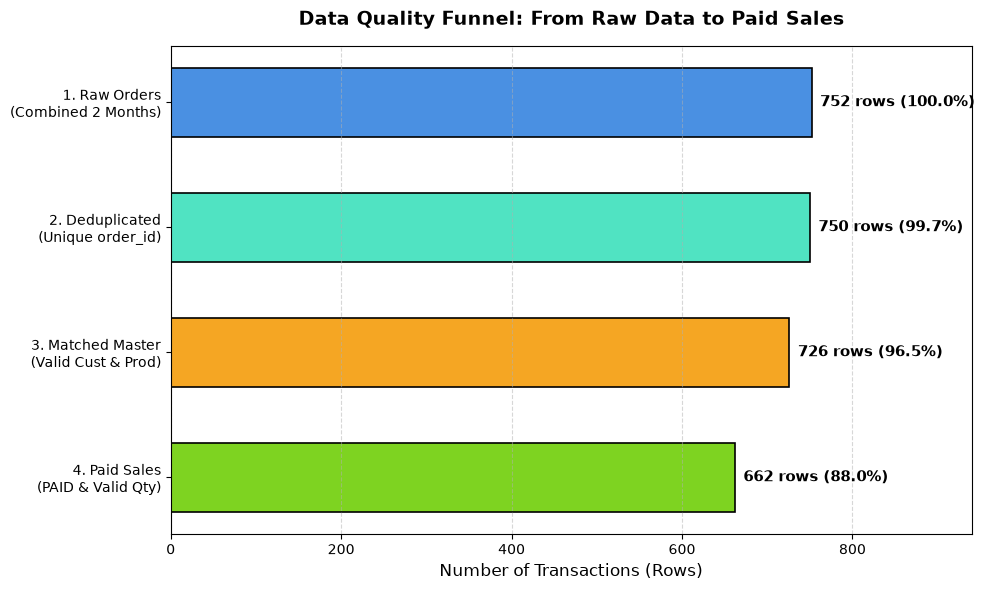

📊 บันทึกรูปภาพกราฟไว้ที่: /Users/gatunyu/Documents/J_Tea_Work/dw_lab/week08/output/data_quality_funnel.png


In [82]:
# 9. Challenge เพิ่มเติม
# ฟังก์ชัน validate_data() ตรวจสอบความถูกต้องของ Data และพล็อตกราฟ Data Quality Funnel
import matplotlib.pyplot as plt

def validate_data(df_fact, df_customers_master, df_products_master):
    """
    ฟังก์ชันตรวจสอบ Data Integrity และ Business Rules สำหรับ fact_sales:
    1. Uniqueness
    2. Referential Integrity
    3. Range Validation (quantity, unit_price, discount)
    4. Payment Status (PAID)
    """
    
    # 1. ตรวจสอบ Uniqueness
    dup_count = df_fact["order_id"].duplicated().sum()
    assert dup_count == 0, f"AssertionError: พบ order_id ซ้ำกันจำนวน {dup_count} รายการ!"
    print("  ✔️ 1. Uniqueness check passed: order_id ไม่ซ้ำกัน 100%")
    
    # 2. ตรวจสอบ Referential Integrity
    unmatched_cust = (~df_fact["customer_id"].isin(df_customers_master["customer_id"])).sum()
    assert unmatched_cust == 0, f"AssertionError: พบ customer_id ที่ไม่มีใน CRM Master จำนวน {unmatched_cust} รายการ!"
    
    unmatched_prod = (~df_fact["product_id"].isin(df_products_master["product_id"])).sum()
    assert unmatched_prod == 0, f"AssertionError: พบ product_id ที่ไม่มีใน Product Master จำนวน {unmatched_prod} รายการ!"
    print("  ✔️ 2. Referential Integrity check passed: ลูกค้าและสินค้าตรงกับ Master 100%")
    
    # 3. ตรวจสอบ Range Validation (ค่าที่อยู่นอกช่วง)
    invalid_qty = (df_fact["quantity"] <= 0).sum()
    assert invalid_qty == 0, f"AssertionError: พบ quantity <= 0 จำนวน {invalid_qty} รายการ!"
    
    invalid_price = (df_fact["unit_price"] <= 0).sum()
    assert invalid_price == 0, f"AssertionError: พบ unit_price <= 0 จำนวน {invalid_price} รายการ!"
    
    invalid_disc = ((df_fact["discount"] < 0) | (df_fact["discount"] > 1)).sum()
    assert invalid_disc == 0, f"AssertionError: พบ discount ไม่อยู่ในช่วง [0, 1] จำนวน {invalid_disc} รายการ!"
    print("  ✔️ 3. Range Validation check passed: quantity > 0, unit_price > 0, discount [0, 1]")
    
    # 4. ตรวจสอบสถานะการชำระเงิน (ถ้ามีคอลัมน์ payment_status หรือตรวจสอบจากที่กรองแล้ว)
    if "payment_status" in df_fact.columns:
        unpaid = (df_fact["payment_status"] != "PAID").sum()
        assert unpaid == 0, f"AssertionError: พบรายการที่ไม่ใช่ PAID จำนวน {unpaid} รายการ!"
        print("  ✔️ 4. Payment status check passed: ทุกรายการสถานะเป็น PAID")

    print("🎉 ผลการตรวจสอบ: ข้อมูลทั้งหมดถูกต้องสมบูรณ์ตาม Business Rules ทุกประการ!\n")


# เรียกใช้งานฟังก์ชัน validate_data กับ fact_sales
validate_data(df_sales_validated, df_customers, df_products)



# สร้างกราฟ Data-Quality Funnel: raw → deduplicated → matched → paid sales

stage_raw = len(df_orders_01) + len(df_orders_02)
stage_dedup = len(df_orders)
stage_matched = len(df_valid_orders)
stage_paid = len(df_sales_validated)

funnel_stages = [
    "1. Raw Orders\n(Combined 2 Months)",
    "2. Deduplicated\n(Unique order_id)",
    "3. Matched Master\n(Valid Cust & Prod)",
    "4. Paid Sales\n(PAID & Valid Qty)"
]
funnel_values = [stage_raw, stage_dedup, stage_matched, stage_paid]

# สร้างแนวกราฟ Funnel Bar Chart
plt.figure(figsize=(10, 6))
colors = ["#4A90E2", "#50E3C2", "#F5A623", "#7ED321"]
bars = plt.barh(funnel_stages[::-1], funnel_values[::-1], color=colors[::-1], height=0.55, edgecolor="black", linewidth=1.2)

# ใส่ตัวเลขและ % บนแท่งกราฟ
for bar, val in zip(bars, funnel_values[::-1]):
    pct_from_raw = (val / stage_raw) * 100
    plt.text(
        bar.get_width() + 10, 
        bar.get_y() + bar.get_height() / 2, 
        f"{val:,} rows ({pct_from_raw:.1f}%)", 
        va="center", 
        ha="left", 
        fontsize=11, 
        fontweight="bold"
    )

plt.title("Data Quality Funnel: From Raw Data to Paid Sales", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Transactions (Rows)", fontsize=12)
plt.xlim(0, max(funnel_values) * 1.25)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()

# บันทึกรูปกราฟลง output
plt.savefig(OUTPUT / "data_quality_funnel.png", dpi=300)
plt.show()

print(f"📊 บันทึกรูปภาพกราฟไว้ที่: {OUTPUT / 'data_quality_funnel.png'}")
